# IDs: 323084962 and 209361658

# Advanced Topics in Machine Learning for Computational Biology

## Homework 2: Antimicrobial Property prediction with tree ensembles and graph neural networks


Figure and data from: A Deep Learning Approach to Antimicrobial Discovery, Stokes et al. Cell 2020.


 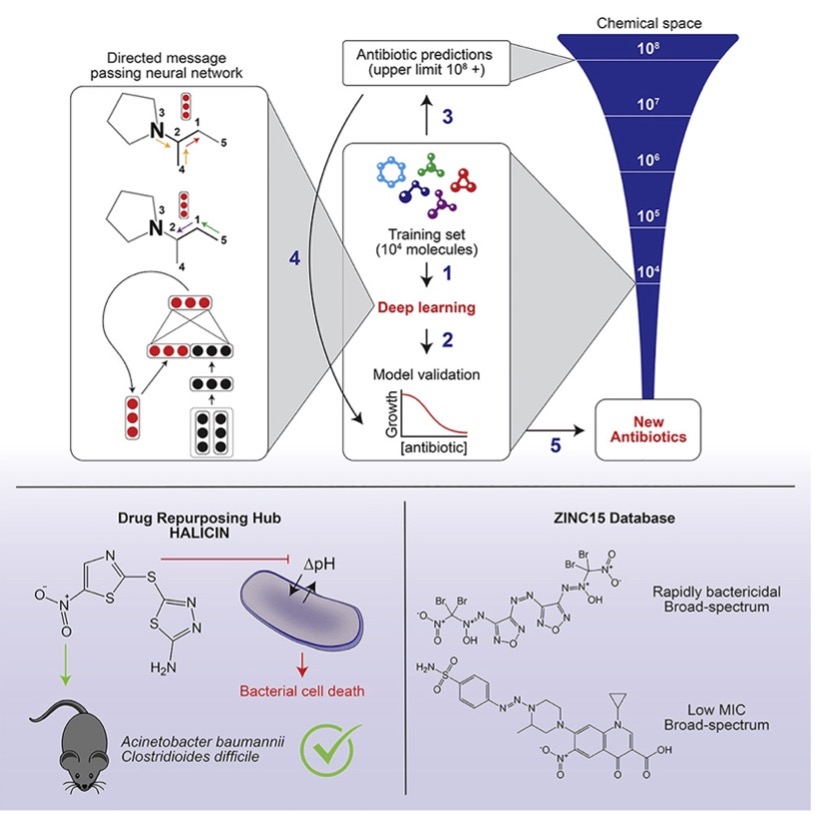





## Download data & install packages

In [1]:
# Colab setup: download the dataset and install the dependencies.
# Both steps are skipped automatically when the data and packages are already available.
import os, importlib.util

if not os.path.isdir('MLCB_2024_HW2_Data') and not os.path.isfile('training_table.xlsx'):
    !wget -q https://github.com/jertubiana/jertubiana.github.io/raw/master/misc/MLCB_2024_HW2_Data.zip
    !unzip -q MLCB_2024_HW2_Data.zip

if importlib.util.find_spec('torch_geometric') is None:
    !pip install -q matplotlib seaborn shap torch_geometric rdkit

# Package & data loading

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from rdkit import Chem

sns.set_theme(style='whitegrid')

# Resolve the data location for both Colab and local execution.
DATA_DIR = '/content/MLCB_2024_HW2_Data' if os.path.isdir('/content/MLCB_2024_HW2_Data') else '.'

# First experimental round: used for training and evaluating the model.
table_first_round_molecules = pd.read_excel(os.path.join(DATA_DIR, 'training_table.xlsx'), skiprows=1, sheet_name='S1B')
table_first_round_molecules['Class_Label'] = table_first_round_molecules['Activity'].map(lambda x: 1 if x == 'Active' else 0)

print('Training table')
display(table_first_round_molecules.head())

# Second round (Drug Repurposing Hub): used for inference only.
table_evaluation_molecules = pd.read_excel(os.path.join(DATA_DIR, 'DrugRepurposing_Hub_predictions.xlsx'), skiprows=1, sheet_name='S2B').drop(columns=['Unnamed: 6', 'Broad_ID'])
print('Evaluation table')
display(table_evaluation_molecules.head())

Training table


,Mean_Inhibition,SMILES,Name,Activity,Class_Label
0,0.041572,Cc1cc(O)c(C(=O)NC(C(=O)NC2C(=O)N3C(C(=O)O)=C(C...,CEFPIRAMIDE,Active,1
1,0.041876,CON=C1CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3C2CC2)CC...,GEMIFLOXACIN MESYLATE,Active,1
2,0.041916,CCC(C)CCCCC(=O)NC(CCN)C(=O)NC(C(=O)NC(CCN)C(=O...,POLYMYXIN B SULFATE,Active,1
3,0.041964,Cl.N=C(N)n1cccn1,PRAXADINE HYDROCHLORIDE,Active,1
4,0.042295,Cl.Cl.N=C(NCCCCCCNC(=N)NC(=N)Nc1ccc(Cl)cc1)NC(...,CHLORHEXIDINE DIHYDROCHLORIDE,Active,1


Evaluation table


,Name,SMILES,Pred_Score,Mean_Inhibition,ClinTox (low = less predicted toxicity)
0,cefmenoxime,CO\N=C(\C(=O)NC1C2SCC(CSc3nnnn3C)=C(N2C1=O)C(O...,0.967200,0.04505,0.001422
1,ulifloxacin,CC1Sc2c(C(O)=O)c(=O)c3cc(F)c(cc3n12)N1CCNCC1,0.957037,0.05040,0.958267
2,cefotiam,CN(C)CCn1nnnc1SCC1=C(N2[C@H](SC1)[C@H](NC(=O)C...,0.952527,0.04495,0.229829
3,ceftriaxone,CO\N=C(/C(=O)N[C@H]1[C@H]2SCC(CSc3nc(=O)c(O)nn...,0.942160,0.04250,0.011146
4,balofloxacin,CNC1CCCN(C1)c1c(F)cc2c(c1OC)n(cc(C(O)=O)c2=O)C...,0.931109,0.04115,0.927147


# Part 0: Parsing the data into Tabular Machine Learning format using the RDKIT package

In this section we:
- Convert each SMILE into a RDKIT Molecule class instance, which has many useful methods.

- Calculate various physio-chemical features for each molecule using RDKIT pre-provided functions. Example of features include number of atoms and bonds of each type, number of hydrogen bond donor and acceptors, etc.


In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, MolSurf
import numpy as np


def extract_chemical_features(list_molecules):
  def num_atoms(mol):
    atom_counts = {
        'Total': 0,
        'Carbon': 0,
        'Nitrogen': 0,
        'Oxygen': 0,
        'Sulfur': 0,
        'Fluorine': 0,
        'Phosphate':0,
        'Chlorine':0,
        'Other':0,
    }
    for atom in mol.GetAtoms():
      atom_counts['Total'] +=1
      atom_type = atom.GetSymbol()
      if atom_type == 'C':
          atom_counts['Carbon'] += 1
      elif atom_type == 'N':
          atom_counts['Nitrogen'] += 1
      elif atom_type == 'O':
          atom_counts['Oxygen'] += 1
      elif atom_type == 'S':
          atom_counts['Sulfur'] += 1
      elif atom_type == 'F':
          atom_counts['Fluorine'] += 1
      elif atom_type == 'P':
          atom_counts['Phosphate'] += 1
      elif atom_type == 'Cl':
          atom_counts['Chlorine'] += 1
      else:
          atom_counts['Other'] += 1
    return atom_counts


  def num_bonds(mol):
    bond_counts = {
        'Total': 0,
        'Single': 0,
        'Double': 0,
        'Triple': 0,
        'Aromatic': 0,
    }
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
      bond_counts['Total'] +=1
      bond_type = bond.GetBondType()
      if bond_type == Chem.BondType.SINGLE:
          bond_counts['Single'] += 1
      elif bond_type == Chem.BondType.DOUBLE:
          bond_counts['Double'] += 1
      elif bond_type == Chem.BondType.TRIPLE:
          bond_counts['Triple'] += 1
      elif bond_type == Chem.BondType.AROMATIC:
          bond_counts['Aromatic'] += 1
    return bond_counts


  """
  Extract chemical features for a list of molecules.

  Parameters:
  list_molecules (list): List of small molecules (RDKIT class instances).
  Returns:
  pandas.DataFrame: Table of descriptors.
  """

  # List to store results
  results = []

  # Define descriptors to compute (MOE-like)
  descriptors = {
      'MolWt': Descriptors.MolWt,  # Molecular weight
      'LogP': Crippen.MolLogP,     # Octanol-water partition coefficient
      'TPSA': MolSurf.TPSA,        # Topological polar surface area
      'HBD': Lipinski.NumHDonors,  # Number of hydrogen bond donors
      'HBA': Lipinski.NumHAcceptors,  # Number of hydrogen bond acceptors
      'RotBonds': Lipinski.NumRotatableBonds,  # Number of rotatable bonds
      'NumAromRings': Descriptors.NumAromaticRings,  # Number of aromatic rings
      'NumHeteroatoms': Descriptors.NumHeteroatoms,  # Number of heteroatoms
      'FractionSP3': Descriptors.FractionCSP3,  # Fraction of sp3 carbons
      'MolarRefractivity': Crippen.MolMR,  # Molar refractivity (MOE's mr)
      'NumAtoms': num_atoms,
      'NumBonds': num_bonds,
  }

  all_mol_features = []
  for molecule in list_molecules:
    mol_features = {}
    for desc_name, desc_func in descriptors.items():
      results = desc_func(molecule)
      if isinstance(results,dict):
        for key, value in results.items():
          mol_features[f'{desc_name}{key}'] = value
      else:
        mol_features[desc_name] = results
    all_mol_features.append(mol_features)
  return pd.DataFrame(all_mol_features)




# SMILES is a string-based representation of molecules.
first_round_molecules_smiles = table_first_round_molecules['SMILES']
evaluation_molecules_smiles = table_evaluation_molecules['SMILES']

# We first turn each molecule into an instance of the RDKIT molecule.
first_round_molecules_rdkit = [Chem.MolFromSmiles(smiles) for smiles in first_round_molecules_smiles]
evaluation_molecules_rdkit = [Chem.MolFromSmiles(smiles) for smiles in evaluation_molecules_smiles]

# Discard examples for which conversion failed.
first_round_molecules_success = [i for i in range(len(first_round_molecules_rdkit)) if first_round_molecules_rdkit[i] is not None]
evaluation_molecules_success = [i for i in range(len(evaluation_molecules_rdkit)) if evaluation_molecules_rdkit[i] is not None]

print(f'Molecule construction failed for { len(first_round_molecules_rdkit)-len(first_round_molecules_success) }/{len(first_round_molecules_rdkit)} examples in the first round dataset')
print(f'Molecule construction failed for {len(evaluation_molecules_rdkit) - len(evaluation_molecules_success)}/{len(evaluation_molecules_rdkit)} examples in the evaluation dataset')

table_first_round_molecules = table_first_round_molecules.iloc[first_round_molecules_success].reset_index()
table_evaluation_molecules = table_evaluation_molecules.iloc[evaluation_molecules_success].reset_index()

first_round_molecules_rdkit = [mol for mol in first_round_molecules_rdkit if mol is not None]
evaluation_molecules_rdkit = [mol for mol in evaluation_molecules_rdkit if mol is not None]


features_first_round_molecules = extract_chemical_features(first_round_molecules_rdkit)
features_first_round_molecules.index = table_first_round_molecules['Name']

features_evaluation_molecules = extract_chemical_features(evaluation_molecules_rdkit)
features_evaluation_molecules.index = table_evaluation_molecules['Name']

print('Example of descriptors for 10 molecules')
display(features_first_round_molecules.head())






[14:07:12] Explicit valence for atom # 16 Al, 6, is greater than permitted


Molecule construction failed for 1/2335 examples in the first round dataset
Molecule construction failed for 0/4496 examples in the evaluation dataset


Example of descriptors for 10 molecules


,MolWt,LogP,TPSA,HBD,HBA,RotBonds,NumAromRings,NumHeteroatoms,FractionSP3,MolarRefractivity,...,NumAtomsSulfur,NumAtomsFluorine,NumAtomsPhosphate,NumAtomsChlorine,NumAtomsOther,NumBondsTotal,NumBondsSingle,NumBondsDouble,NumBondsTriple,NumBondsAromatic
Name,,,,,,,,,,,,,,,,,,,,,
CEFPIRAMIDE,612.650,0.32672,212.76,5,12,9,3,17,0.280000,148.1593,...,2,0,0,0,0,46,24,5,0,17
GEMIFLOXACIN MESYLATE,485.494,0.47000,177.41,3,9,5,2,14,0.473684,117.8653,...,1,1,0,0,0,35,19,5,0,11
POLYMYXIN B SULFATE,1301.578,-5.89760,565.26,20,20,29,1,34,0.696429,330.3537,...,1,0,0,0,0,90,71,13,0,6
PRAXADINE HYDROCHLORIDE,146.581,0.04647,67.69,2,2,0,1,5,0.000000,36.7871,...,0,0,0,1,0,8,2,1,0,5
CHLORHEXIDINE DIHYDROCHLORIDE,578.380,5.01888,167.58,10,4,9,2,14,0.272727,156.2970,...,0,0,0,4,0,35,19,4,0,12


# Part I: Exploratory Data Analysis

1.	Display, as a scatter plot, the distribution of the number of atoms and covalent bonds per molecule. Color by the measured  class. Is there a relationship between molecule size and activity?

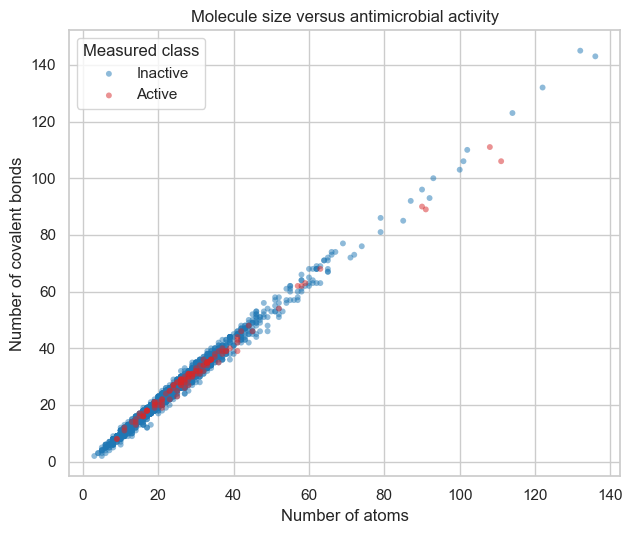

Inactive: 2214 molecules, mean atoms = 23.6, mean bonds = 24.8
Active: 120 molecules, mean atoms = 30.5, mean bonds = 32.0


In [4]:
labels = table_first_round_molecules['Class_Label'].values
n_atoms = features_first_round_molecules['NumAtomsTotal'].values
n_bonds = features_first_round_molecules['NumBondsTotal'].values

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for cls, name, color in [(0, 'Inactive', 'tab:blue'), (1, 'Active', 'tab:red')]:
    mask = labels == cls
    ax.scatter(n_atoms[mask], n_bonds[mask], s=18, alpha=0.5, edgecolor='none', color=color, label=name)
ax.set_xlabel('Number of atoms')
ax.set_ylabel('Number of covalent bonds')
ax.set_title('Molecule size versus antimicrobial activity')
ax.legend(title='Measured class')
plt.tight_layout()
plt.show()

for cls, name in [(0, 'Inactive'), (1, 'Active')]:
    m = labels == cls
    print(f'{name}: {m.sum()} molecules, mean atoms = {n_atoms[m].mean():.1f}, mean bonds = {n_bonds[m].mean():.1f}')

**Answer**

Since there are active and inactive at both higher and lower molecule sizes, we can say with high confidence that there isnt a strong connection between size and activity.

2.	For each of the following five features:
*   Octanol-water partition coefficient
*   Molecular weight
*   Number of hydrogen bond donors
*   Number of hydrogen bond acceptors
*   Number of aromatic rings


Display the histogram of the feature value, for each of the two classes. Which feature(s) have the strongest discriminative power?


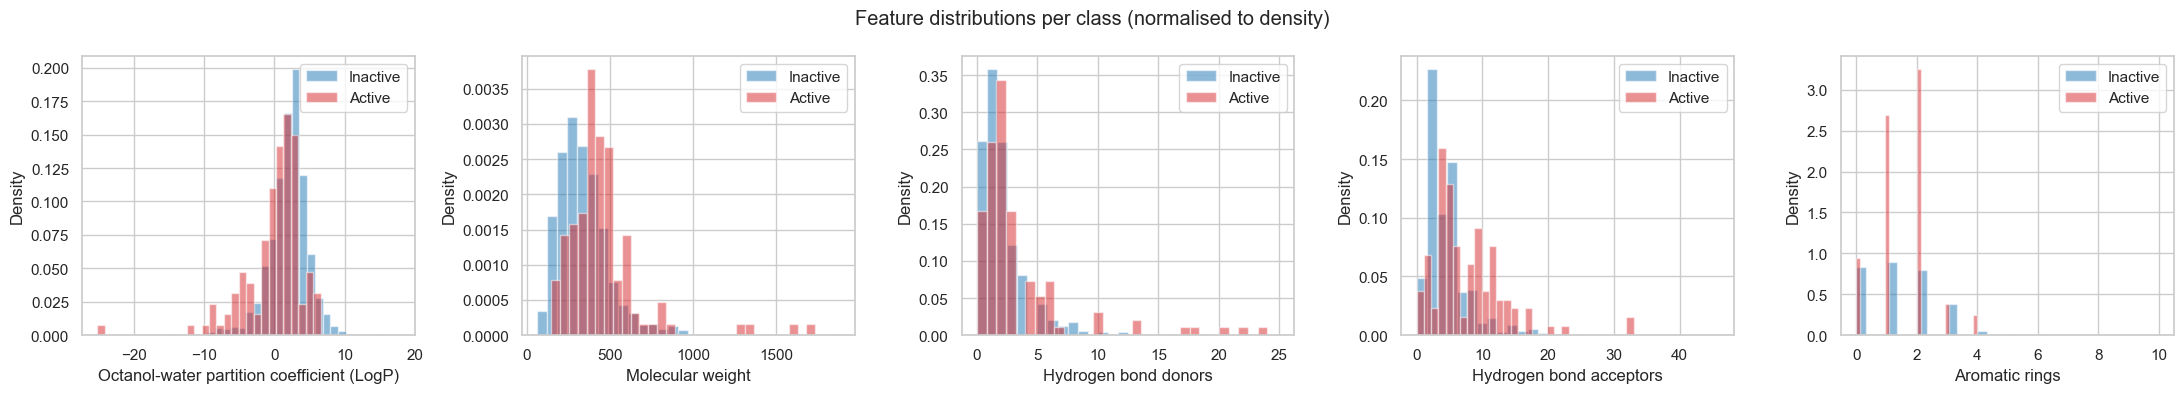

Class-conditional means (active vs inactive):
  LogP           active =   -0.032   inactive =    2.042   difference = -2.074
  MolWt          active =  457.523   inactive =  344.903   difference = +112.620
  HBD            active =    3.317   inactive =    2.060   difference = +1.257
  HBA            active =    7.692   inactive =    4.803   difference = +2.889
  NumAromRings   active =    1.508   inactive =    1.352   difference = +0.156


In [5]:
selected_features = {
    'LogP': 'Octanol-water partition coefficient (LogP)',
    'MolWt': 'Molecular weight',
    'HBD': 'Hydrogen bond donors',
    'HBA': 'Hydrogen bond acceptors',
    'NumAromRings': 'Aromatic rings',
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (column, title) in zip(axes, selected_features.items()):
    for cls, name, color in [(0, 'Inactive', 'tab:blue'), (1, 'Active', 'tab:red')]:
        values = features_first_round_molecules[column].values[labels == cls]
        ax.hist(values, bins=30, density=True, alpha=0.5, color=color, label=name)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()
fig.suptitle('Feature distributions per class (normalised to density)')
plt.tight_layout()
plt.show()

print('Class-conditional means (active vs inactive):')
for column in selected_features:
    active = features_first_round_molecules[column].values[labels == 1].mean()
    inactive = features_first_round_molecules[column].values[labels == 0].mean()
    print(f'  {column:14s} active = {active:8.3f}   inactive = {inactive:8.3f}   difference = {active - inactive:+.3f}')

**Answer**

The features with the strongest separating power are molecular weight and the hydrogen bond acceptor count, since they show the largest separation between the classes in the plots. The octanol-water partition coefficient also carries some signal. Hydrogen bond donors mostly help at extreme values: low counts show up for both active and inactive molecules, but high counts are dominated by active ones.

# Part II: Data Partition

Our training data is NOT independently distributed because many known antimicrobial molecules were obtained by small modifications of previously known molecules. Indeed, similar molecules often have similar chemical activity. We thus need to partition the data with grouped splits.


Specifically, our goal is to build a model that can generalize well to unseen molecules. To this end, we want to make sure that our molecules from the train, validation and test are “dissimilar enough”.


We will use the Tanimoto similarity, a custom metric for calculating similarity between molecules (from 0 = dissimilar to 1 = maximally similar).



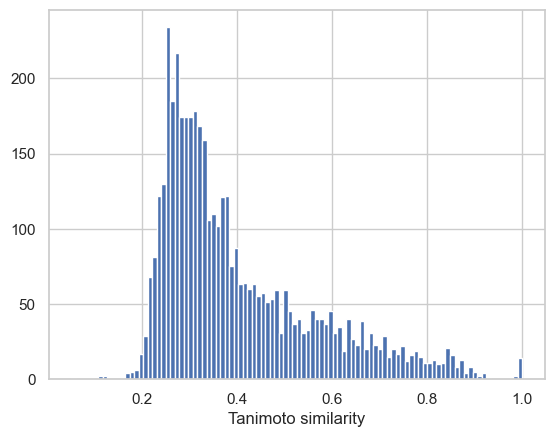

Selected Tanimoto similarity Cut-off: 0.50
Created 1138 groups
Sizes of train/val/test: 1638, 312, 384
Proportion of positive labels in train/val/test: 0.052, 0.058, 0.044
Sizes of the five folds: [282, 316, 575, 421, 356]
Proportion of positive labels in the five folds: [np.float64(0.03900709219858156), np.float64(0.012658227848101266), np.float64(0.04869565217391304), np.float64(0.08076009501187649), np.float64(0.07303370786516854)]


In [6]:
from rdkit.Chem import AllChem, DataStructs
from scipy.sparse import csr_array
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold,GroupKFold
from rdkit.Chem import rdFingerprintGenerator

def calculate_morgan_fingerprints(list_molecules, radius=2, fpSize=1024):
  '''
  A count-based representation of small molecules (e.g., how many occurence of O with double bond to C, etc.)
  '''
  mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius,fpSize=fpSize)
  fingerprints = [mfpgen.GetFingerprint(mol) for mol in list_molecules]
  return fingerprints


def calculate_tanimoto_similarity(fp1,fp2):
    """
    Calculate the Tanimoto similarity between two molecules given their Morgan fingerprints.

    Parameters:
    fp1 (str): Morgan Fingerprints of the first molecule.
    fp2 (str): Morgan Fingerprints of the second molecule.

    Returns:
    float: Tanimoto similarity score (0 to 1), or None if invalid SMILES.
    """
    return DataStructs.TanimotoSimilarity(fp1, fp2)



first_round_molecules_morgan_fingerprints = calculate_morgan_fingerprints(first_round_molecules_rdkit)
evaluation_molecules_morgan_fingerprints = calculate_morgan_fingerprints(evaluation_molecules_rdkit)


nFirstRoundMols = len(first_round_molecules_rdkit)
nEvaluationMols = len(evaluation_molecules_rdkit)


tanimoto_similarities_first_round = np.zeros([nFirstRoundMols,nFirstRoundMols])


## Calculate Tanimoto similarities within set of molecules from first round.
for i in range(nFirstRoundMols):
  for j in range(i+1,nFirstRoundMols):
    tanimoto_similarities_first_round[i,j] = calculate_tanimoto_similarity(first_round_molecules_morgan_fingerprints[i],first_round_molecules_morgan_fingerprints[j])
    tanimoto_similarities_first_round[j,i] = tanimoto_similarities_first_round[i,j]


## Calculate Tanimoto similarities between set of molecules from first round and set from second round.


tanimoto_similarities_evaluation_to_first_round = np.zeros([nEvaluationMols,nFirstRoundMols])
for i in range(nEvaluationMols):
  for j in range(nFirstRoundMols):
    tanimoto_similarities_evaluation_to_first_round[i,j] = calculate_tanimoto_similarity(evaluation_molecules_morgan_fingerprints[i],first_round_molecules_morgan_fingerprints[j])


## Explain this code section for Q4/5.

similarity_to_closest_labeled_molecule = tanimoto_similarities_evaluation_to_first_round.max(axis=1)
plt.hist(similarity_to_closest_labeled_molecule,bins=100)
plt.xlabel('Tanimoto similarity')
plt.show()

tanimoto_cut_off = np.median(similarity_to_closest_labeled_molecule)

tanimoto_cut_off = 0.5

print(f'Selected Tanimoto similarity Cut-off: {tanimoto_cut_off:.2f}')

binary_similarity_graph = tanimoto_similarities_first_round >= tanimoto_cut_off
n_groups, groups = connected_components(csgraph=csr_array(binary_similarity_graph), directed=False, return_labels=True)

print(f'Created {n_groups} groups')


train_test_split = GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=5)
[(train_and_val_index, test_index)] = train_test_split.split(features_first_round_molecules,table_first_round_molecules['Class_Label'],groups)



## Use this train/val split for training the GNN.
train_val_split = GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=0)
[(train_index_, val_index_)] = train_val_split.split(features_first_round_molecules.iloc[train_and_val_index],table_first_round_molecules['Class_Label'].iloc[train_and_val_index],groups[train_and_val_index])

train_index = train_and_val_index[train_index_]
val_index = train_and_val_index[val_index_]


print('Sizes of train/val/test: %s, %s, %s' % (len(train_index), len(val_index), len(test_index)) )

print( 'Proportion of positive labels in train/val/test: %.3f, %.3f, %.3f'%  (table_first_round_molecules['Class_Label'].iloc[train_index].mean(),
                                                                              table_first_round_molecules['Class_Label'].iloc[val_index].mean(),
                                                                              table_first_round_molecules['Class_Label'].iloc[test_index].mean())
)


## Use this 5-fold cross-validation for training and evaluating the feature-based model.

# cross_val_split = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=0)
cross_val_split = GroupKFold(n_splits=5,shuffle=True,random_state=5)

cv_indices_ = list( cross_val_split.split(features_first_round_molecules.iloc[train_and_val_index], table_first_round_molecules['Class_Label'].iloc[train_and_val_index], groups[train_and_val_index]) )

cv_indices = [ (train_and_val_index[cv_index_[0]], train_and_val_index[cv_index_[1]]) for cv_index_ in cv_indices_]


print('Sizes of the five folds: %s' % ( [len(cv[1]) for cv in cv_indices]) )

print('Proportion of positive labels in the five folds: %s' % ( [ table_first_round_molecules['Class_Label'].iloc[cv[1]].mean() for cv in cv_indices]) )



3.	Justify the choice of threshold used for Tamimoto similarity.

**Answer.** The threshold is set to 0.5. The code computes the median similarity of each evaluation molecule to its closest training molecule, then fixes the cut-off at 0.5. This ties the split difficulty directly to the deployment task: at inference time the model sees Drug Repurposing Hub molecules whose typical nearest-neighbour similarity to the training set is close to this cut-off. By grouping training molecules at the same similarity level, the held-out folds are at least as dissimilar from one another as a typical screening molecule is from the training data, so the cross-validation score is a fair estimate of real screening performance.

0.5 is also a sensible operating point for the grouping itself. A much lower threshold connects almost every molecule into a handful of giant components, leaving too few groups to split. A much higher threshold leaves near-duplicate scaffolds in separate groups, so they leak across train and test and inflate the score. 0.5 is a compromise between these two failure modes.

Raising the cut-off has a price. We should be cautious about applying the model to molecules with Tanimoto similarity below 0.5 to the training set, since we have no guarantee it generalizes past that point.


4.	Explain how the algorithm prevents two molecules with high Tamimoto similarity from ending up in a different split.

**Answer**

The code builds an undirected graph (`binary_similarity_graph`) where two molecules are connected whenever their Tanimoto similarity is at least the cut-off. `connected_components` then assigns every molecule a group id, so any two molecules joined by a chain of pairwise-similar molecules get the same id (the similarity is propagated transitively through the connected component). The splitters (`GroupShuffleSplit` for train/test and validation, `GroupKFold` for cross-validation) partition by group id and never put a single group on both sides of a split.

Because of that, two very similar molecules share an edge, share a group, and always land in the same fold. They can't be separated into train and test, which is what prevents leakage from near-duplicate molecules showing up on both sides.

# Part III: Training a tree ensemble model on the Dataset.

5.	 Throughout the rest of the homework, the metric for model selection and evaluation is chosen to be the Area under the Precision Recall Curve (implemented as the “average_precision_score” in sklearn). Justify this choice of metric given the problem considered.


**Answer**

This metric makes sense for this project due to two reasosn:
1. Dataset imbalance - we have many more negative samples then positive samples (120 active, 2300 inactive). This means we have to be more sensitive to postive cses, otherwise we could get bloated success metrics due to being correct mostly on the negative, which are not important for this task.

2. focus on postives - the task at hand is virtual screening. the cost of a false positive is low, and for false negative is high, since the aim is to filter molecules for potential drugs, and all results are later verified. we do not want to miss potential drugs, and we dont care too much for testing a few more molecules

6.	Using sklearn’s HistGradBoosting (or xgboost/LightGBM), build a Gradient Boosted Tree classifier. Select the optimal hyperparameters (number of iterations; learning rate; regularization strength; number of leaves) by cross-validation using the provided group split. Calculate the precision-recall curve over the test set, display it and report the AUCPR. Comment on the quality of the predictions.

Best cross-validated AUCPR: 0.238
Best hyperparameters: {'l2_regularization': 0.0, 'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 31}


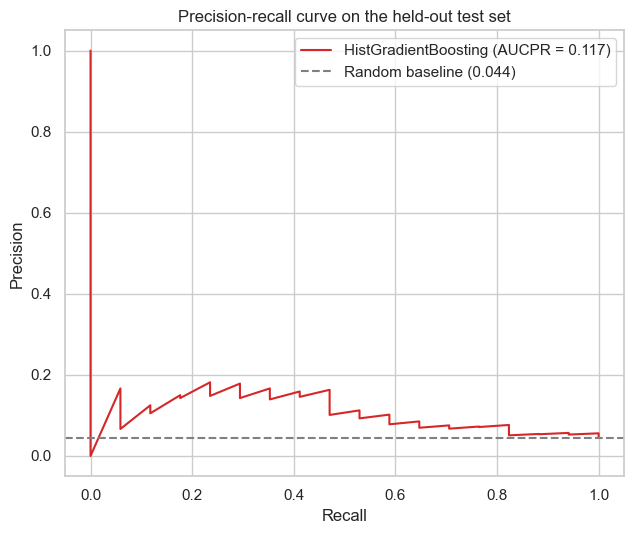

Test AUCPR = 0.117 (random baseline = 0.044, a 2.6x improvement)


In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import ParameterGrid

feature_columns = list(features_first_round_molecules.columns)
X_all = features_first_round_molecules.values
y_all = table_first_round_molecules['Class_Label'].values

X_trainval, y_trainval = X_all[train_and_val_index], y_all[train_and_val_index]
X_test, y_test = X_all[test_index], y_all[test_index]

param_grid = {
    'max_iter': [200, 400],
    'learning_rate': [0.03, 0.1],
    'l2_regularization': [0.0, 1.0],
    'max_leaf_nodes': [15, 31],
}


def cross_val_aucpr(params):
    scores = []
    for tr, va in cv_indices:
        clf = HistGradientBoostingClassifier(random_state=0, **params)
        clf.fit(X_all[tr], y_all[tr])
        proba = clf.predict_proba(X_all[va])[:, 1]
        scores.append(average_precision_score(y_all[va], proba))
    return float(np.mean(scores))


cv_results = sorted(((cross_val_aucpr(p), p) for p in ParameterGrid(param_grid)), key=lambda t: t[0], reverse=True)
best_cv_score, best_params = cv_results[0]
print(f'Best cross-validated AUCPR: {best_cv_score:.3f}')
print('Best hyperparameters:', best_params)

best_model = HistGradientBoostingClassifier(random_state=0, **best_params)
best_model.fit(X_trainval, y_trainval)

test_proba = best_model.predict_proba(X_test)[:, 1]
test_aucpr = average_precision_score(y_test, test_proba)
baseline = y_test.mean()

precision, recall, _ = precision_recall_curve(y_test, test_proba)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(recall, precision, color='tab:red', label=f'HistGradientBoosting (AUCPR = {test_aucpr:.3f})')
ax.axhline(baseline, ls='--', color='grey', label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve on the held-out test set')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Test AUCPR = {test_aucpr:.3f} (random baseline = {baseline:.3f}, a {test_aucpr / baseline:.1f}x improvement)')

**Answer**

The test AUCPR is 0.117, about 2.6 times the random baseline of 0.044, so the simple physico-chemical descriptors carry a modest but real signal for ranking active molecules. The precision-recall curve behaves as expected, with precision dropping as recall rises.

The cross-validated AUCPR is 0.238, a bit higher than the test score. The folds are now reasonably balanced, with actives in every fold, so the numbers are more trustworthy than on the earlier split, though the small number of positives still makes them noisy.

# Part IV: Post-hoc explanations of the tree ensemble model

7.	Using sklearn, calculate the feature importance using the Permutation Feature Importance metric over the train and test set. Which features are the most informative?

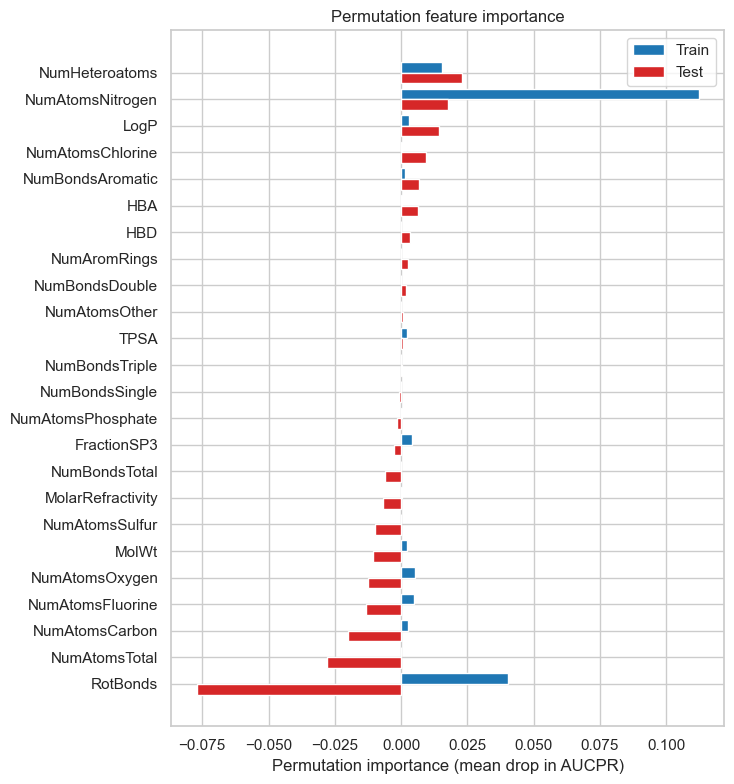

Top 10 features ranked by test-set importance:
         feature    train     test
  NumHeteroatoms 0.015421 0.022918
NumAtomsNitrogen 0.112283 0.017636
            LogP 0.003133 0.014291
NumAtomsChlorine 0.000165 0.009356
NumBondsAromatic 0.001456 0.006623
             HBA 0.000485 0.006201
             HBD 0.000051 0.003380
    NumAromRings 0.000000 0.002605
  NumBondsDouble 0.000000 0.001740
   NumAtomsOther 0.000000 0.000565


In [8]:
from sklearn.inspection import permutation_importance

perm_train = permutation_importance(best_model, X_trainval, y_trainval, scoring='average_precision', n_repeats=20, random_state=0)
perm_test = permutation_importance(best_model, X_test, y_test, scoring='average_precision', n_repeats=20, random_state=0)

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'train': perm_train.importances_mean,
    'test': perm_test.importances_mean,
}).sort_values('test', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 8))
y_pos = np.arange(len(importance_df))
ax.barh(y_pos - 0.2, importance_df['train'], height=0.4, color='tab:blue', label='Train')
ax.barh(y_pos + 0.2, importance_df['test'], height=0.4, color='tab:red', label='Test')
ax.set_yticks(y_pos)
ax.set_yticklabels(importance_df['feature'])
ax.invert_yaxis()
ax.set_xlabel('Permutation importance (mean drop in AUCPR)')
ax.set_title('Permutation feature importance')
ax.legend()
plt.tight_layout()
plt.show()

top_features = importance_df.head(10)['feature'].tolist()
print('Top 10 features ranked by test-set importance:')
print(importance_df.head(10).to_string(index=False))

**Answer.** The most informative features on the test set are the heteroatom and polarity descriptors together with size and flexibility: the number of heteroatoms, the nitrogen and chlorine counts, LogP, the number of aromatic bonds and the hydrogen-bond acceptor and donor counts dominate the ranking. This is consistent with the exploratory analysis, where polarity (LogP), molecular weight and hydrogen-bond capacity separated the classes. Train and test importances agree on this group of descriptors, indicating the model relies on transferable signal; the many near-zero importances (for example individual rare-atom counts) contribute little. LogP ranks near the top here, in line with polarity being a strong single-feature signal in the exploratory analysis.

8.	Using sklearn, display the Partial Dependence Plots (PDP) for the 10 most important features, ordered by importance. Comment on the findings.

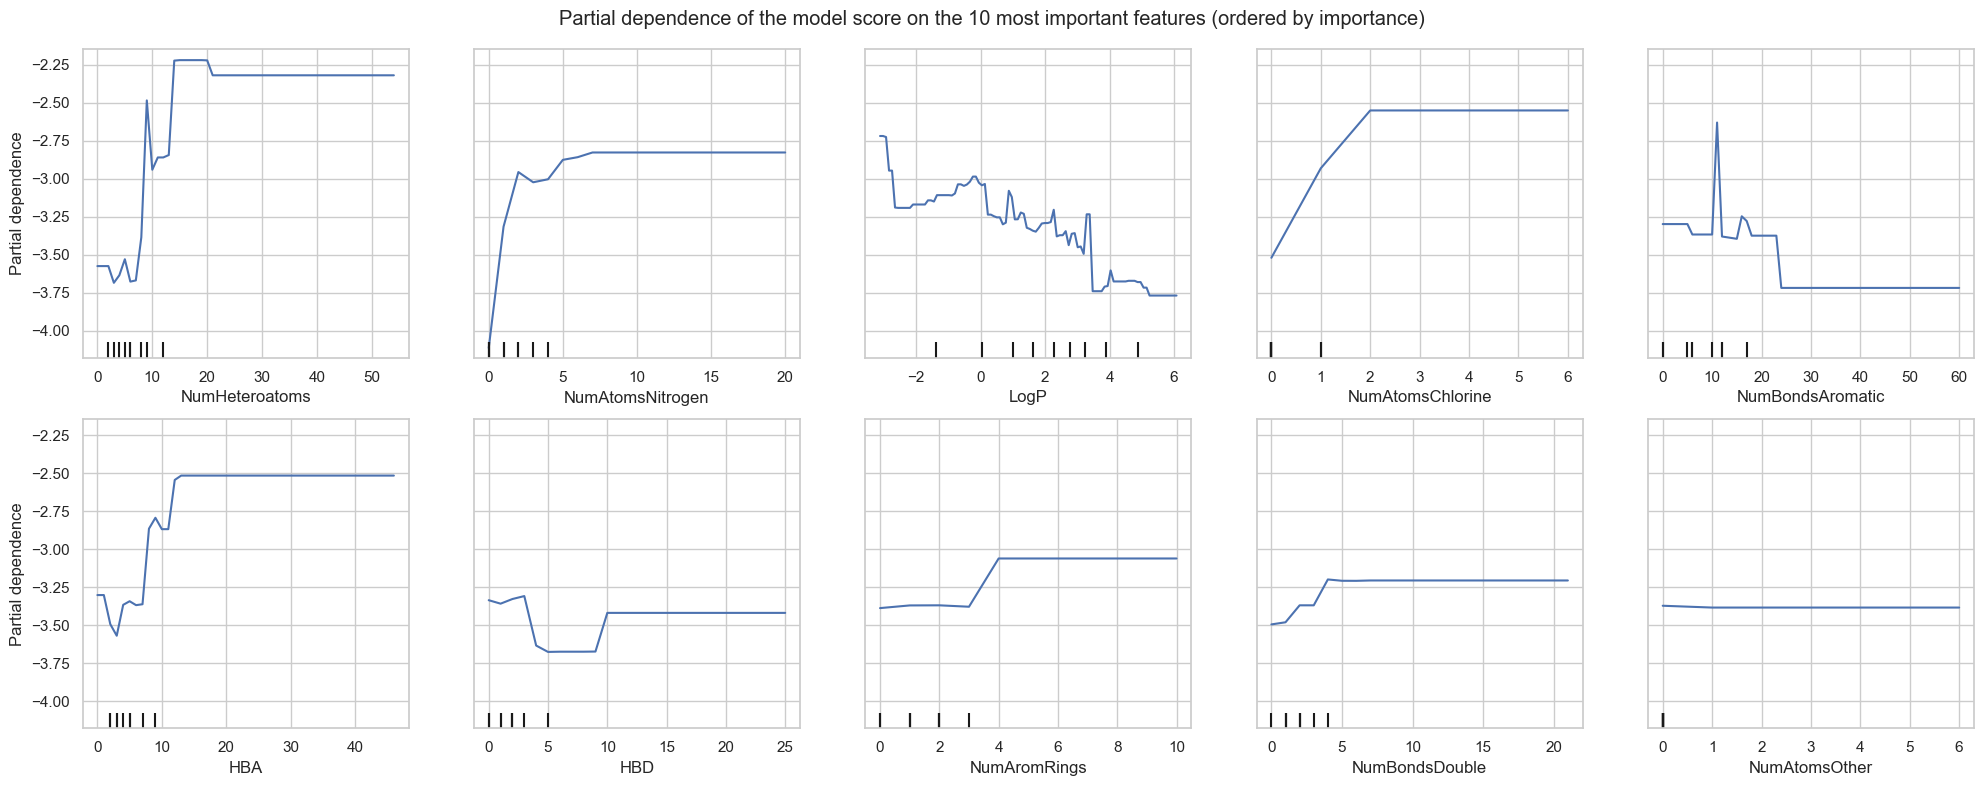

In [9]:
from sklearn.inspection import PartialDependenceDisplay

top_feature_indices = [feature_columns.index(f) for f in top_features]

disp = PartialDependenceDisplay.from_estimator(
    best_model, X_trainval, features=top_feature_indices,
    feature_names=feature_columns, n_cols=5, kind='average',
)
disp.figure_.set_size_inches(20, 8)
disp.figure_.suptitle('Partial dependence of the model score on the 10 most important features (ordered by importance)')
plt.tight_layout()
plt.show()

**Answer**

The partial dependence plots show how the model score moves with each of the ten most important features. Activity tends to go up with the heteroatom count, the nitrogen count and the hydrogen-bond donor/acceptor counts, and to fall again for very large or very rigid molecules, which matches the picture of active compounds being heavier and more polar. Several of the curves are clearly non-linear and flatten into plateaus (threshold effects) rather than rising in a straight line, which is exactly the kind of structure a tree ensemble captures. Since partial dependence averages over the other features, it shows the typical trend per feature but can hide interactions between correlated descriptors such as LogP, the nitrogen count and the heteroatom counts.

9.	Predict the activity of Halicin (SMILE representation: Nc1nnc(Sc2ncc([N+](=O)[O-])s2)s1),  Amoxicilin (SMILE representation: CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O) and calculate the Shapley values associated to these prediction using shap. Are they predicted to be active and why?

Halicin: predicted probability of activity = 0.005 -> inactive
Amoxicillin: predicted probability of activity = 0.275 -> inactive


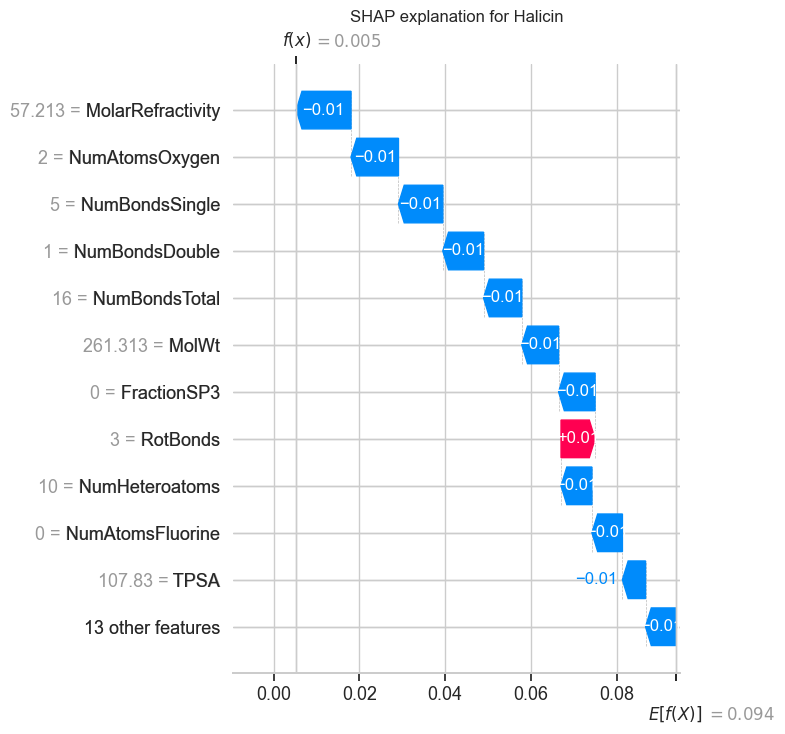

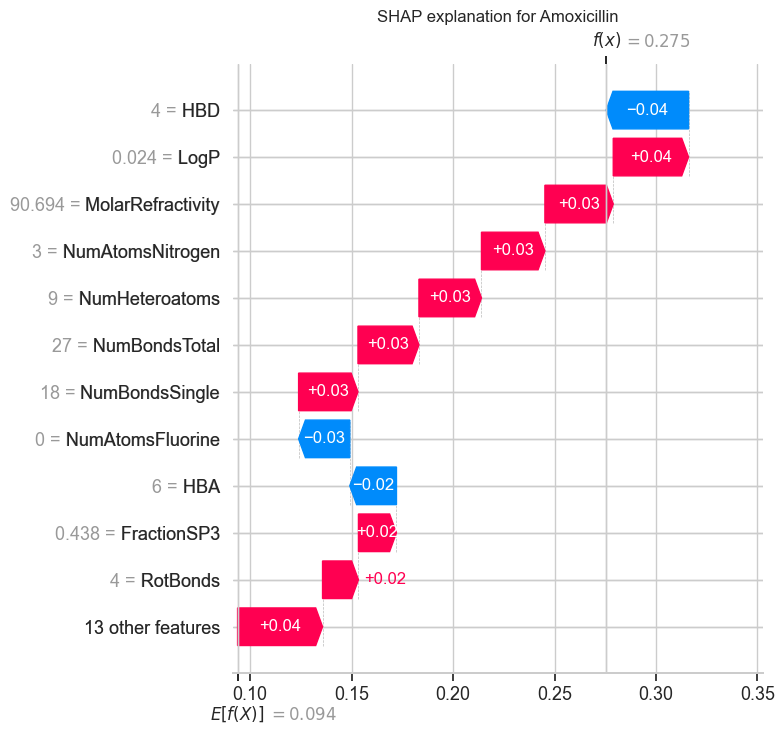

In [10]:
import shap

query_smiles = {
    'Halicin': 'Nc1nnc(Sc2ncc([N+](=O)[O-])s2)s1',
    'Amoxicillin': 'CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O',
}
query_mols = [Chem.MolFromSmiles(s) for s in query_smiles.values()]
query_features = extract_chemical_features(query_mols)[feature_columns]

query_proba = best_model.predict_proba(query_features.values)[:, 1]
for name, p in zip(query_smiles, query_proba):
    print(f'{name}: predicted probability of activity = {p:.3f} -> {"ACTIVE" if p >= 0.5 else "inactive"}')

# SHAP values via a model-agnostic explainer with a background sample from the training set.
background = shap.utils.sample(X_trainval, 100, random_state=0)
explainer = shap.Explainer(lambda data: best_model.predict_proba(data)[:, 1], background, feature_names=feature_columns)
shap_values = explainer(query_features.values)

for i, name in enumerate(query_smiles):
    shap.plots.waterfall(shap_values[i], max_display=12, show=False)
    plt.title(f'SHAP explanation for {name}')
    plt.tight_layout()
    plt.show()

**Answer.** The gradient-boosted tree predicts both molecules to be *inactive*: halicin receives a probability of about 0.005 and amoxicillin about 0.28, both below 0.5. The SHAP waterfall plots explain why by attributing each score to individual descriptors relative to the dataset average. Halicin is a small, structurally unusual nitro-thiadiazole whose physico-chemical descriptors look ordinary, so none of the features the tree relies on push it toward the active class. This is exactly the limitation highlighted by Stokes et al.: hand-engineered descriptors miss structurally novel antibacterials such as halicin, which is why a graph model that reads molecular structure directly is needed. Indeed, in Part VII the graph network does assign halicin a high activity probability, recovering the discovery that the descriptor model misses.

10.    Calculate the Shapley values for all active molecules in the test set and produce a low-dimensional embedding using t-SNE. Do you find that there are clusters of molecules with similar Shapley values? Are they known to have a common mechanism of action?

In [11]:
active_mask = y_test == 1
X_active_test = X_test[active_mask]
active_mask.sum()

np.int64(17)

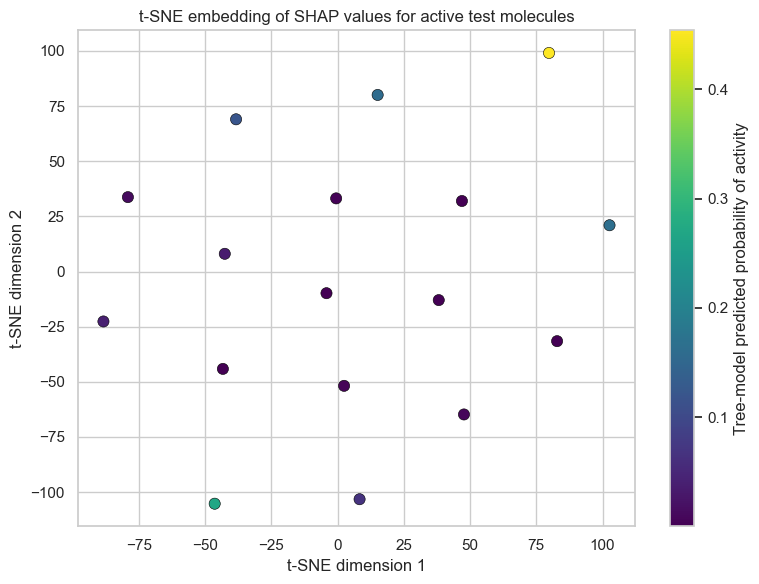

,Molecule_ID,Name,SMILES,Activity,Class_Label,Predicted_probability,tSNE_1,tSNE_2
0,12,RONNEL,COP(=S)(OC)Oc1cc(Cl)c(Cl)cc1Cl,Active,1,0.040425,-88.371567,-22.634331
1,11,BUSPIRONE HYDROCHLORIDE,Cl.O=C1CC2(CCCC2)CC(=O)N1CCCCN1CCN(c2ncccn2)CC1,Active,1,0.012808,-79.132729,33.727856
2,2,GENETICIN,CNC1C(O)C(OC2C(N)CC(N)C(OC3OC(C(C)O)C(O)C(O)C3...,Active,1,0.269593,-46.379951,-105.246292
3,13,DIAVERIDINE,COc1ccc(Cc2cnc(N)nc2N)cc1OC,Active,1,0.000448,-43.286823,-44.132248
4,3,TELENZEPINE HYDROCHLORIDE,Cc1scc2c1N(C(=O)CN1CCN(C)CC1)c1ccccc1NC2=O.Cl,Active,1,0.034294,-42.571156,8.037078
5,9,CEFACLOR,NC(C(=O)NC1C(=O)N2C(C(=O)O)=C(Cl)CSC12)c1ccccc1,Active,1,0.119126,-38.308311,69.010284
6,1,PRAXADINE HYDROCHLORIDE,Cl.N=C(N)n1cccn1,Active,1,0.000352,-4.187375,-9.816270
7,16,PHENYLMERCURIC ACETATE,CC(=O)O[Hg]c1ccccc1,Active,1,0.002374,-0.534916,33.162006
8,8,DONEPEZIL HYDROCHLORIDE,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2.Cl,Active,1,0.004233,2.453600,-51.811443
9,17,DIHYDROSTREPTOMYCIN SESQUISULFATE [5mM/10% aq ...,CNC1C(OC2C(OC3C(O)C(O)C(NC(=N)N)C(O)C3NC(=N)N)...,Active,1,0.065899,8.303305,-103.207466


,Molecule_ID,Name,SMILES,Activity,Class_Label,Predicted_probability,SHAP_MolWt,SHAP_LogP,SHAP_TPSA,SHAP_HBD,...,SHAP_NumAtomsSulfur,SHAP_NumAtomsFluorine,SHAP_NumAtomsPhosphate,SHAP_NumAtomsChlorine,SHAP_NumAtomsOther,SHAP_NumBondsTotal,SHAP_NumBondsSingle,SHAP_NumBondsDouble,SHAP_NumBondsTriple,SHAP_NumBondsAromatic
0,1,PRAXADINE HYDROCHLORIDE,Cl.N=C(N)n1cccn1,Active,1,0.000352,-0.019208,-0.004146,-0.003701,0.000049,...,-0.001100,-0.004559,0.001036,0.000759,0.000012,-0.005731,-0.010373,-0.006267,0.0,-0.002285
1,2,GENETICIN,CNC1C(O)C(OC2C(N)CC(N)C(OC3OC(C(C)O)C(O)C(O)C3...,Active,1,0.269593,0.005648,0.067362,-0.019997,0.009236,...,-0.001805,-0.007248,0.006006,-0.007666,0.000008,0.011365,0.031556,-0.017253,0.0,0.011201
2,3,TELENZEPINE HYDROCHLORIDE,Cc1scc2c1N(C(=O)CN1CCN(C)CC1)c1ccccc1NC2=O.Cl,Active,1,0.034294,0.002520,-0.014704,-0.008475,-0.000563,...,-0.003788,-0.022969,0.005152,0.013262,0.000111,0.004749,0.002784,-0.002940,0.0,0.012655
3,4,TRIMETHOPRIM,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,Active,1,0.001433,-0.008402,-0.005390,-0.004753,0.000368,...,-0.001281,-0.009065,0.001029,-0.004409,0.000016,-0.004123,-0.005339,-0.009690,0.0,-0.010948
4,5,HETACILLIN POTASSIUM,CC1(C)SC2C(N3C(=O)C(c4ccccc4)NC3(C)C)C(=O)N2C1...,Active,1,0.158077,0.006972,0.023072,-0.008475,-0.002301,...,0.003277,-0.030572,0.005593,-0.003660,-0.000226,0.017976,-0.002209,-0.012988,0.0,0.005914
5,6,CLEROCIDIN,CC1CCC2(C)C(C=O)=CCCC2C1(C)CC1OC(O)C(=O)C12CO2,Active,1,0.001335,-0.005134,-0.010251,-0.002496,-0.001003,...,-0.001974,-0.008546,0.002654,-0.003409,0.000015,-0.000319,-0.002663,-0.003514,0.0,-0.002672
6,7,PIPERACILLIN SODIUM,CCN1CCN(C(=O)NC(C(=O)NC2C(=O)N3C2SC(C)(C)C3C(=...,Active,1,0.453752,0.016412,0.076066,0.040354,-0.006102,...,0.026045,-0.014402,0.008191,-0.013567,-0.000138,0.020117,0.005229,0.059216,0.0,0.021661
7,8,DONEPEZIL HYDROCHLORIDE,COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2.Cl,Active,1,0.004233,-0.001254,-0.019700,-0.003480,-0.000783,...,-0.001445,-0.007174,0.002755,0.007502,0.000026,-0.000118,-0.002787,-0.007850,0.0,-0.005408
8,9,CEFACLOR,NC(C(=O)NC1C(=O)N2C(C(=O)O)=C(Cl)CSC12)c1ccccc1,Active,1,0.119126,-0.003050,0.002194,0.001653,0.007895,...,-0.013963,-0.018878,0.004753,0.014246,0.000014,-0.033489,0.006664,0.023377,0.0,0.007708
9,10,DIMENHYDRINATE,CN(C)CCOC(c1ccccc1)c1ccccc1.Cn1c(=O)c2[nH]c(Cl...,Active,1,0.008780,0.005785,-0.008150,-0.006095,-0.000618,...,-0.001171,-0.012311,0.002445,0.010031,0.000020,-0.000490,-0.000255,-0.003923,0.0,-0.035115


In [12]:
from sklearn.manifold import TSNE
import shap

active_mask = y_test == 1
X_active_test = X_test[active_mask]


active_test_metadata = (
    table_first_round_molecules
    .iloc[test_index][['Name', 'SMILES', 'Activity', 'Class_Label']]
    .reset_index(drop=True)
    .loc[active_mask]
    .reset_index(drop=True)
)

background = shap.utils.sample(
    X_trainval,
    min(100, len(X_trainval)),
    random_state=0
)

test_explainer = shap.Explainer(
    lambda data: best_model.predict_proba(data)[:, 1],
    background,
    feature_names=feature_columns
)

active_test_shap = test_explainer(X_active_test)
active_test_shap_df = pd.DataFrame(
    active_test_shap.values,
    columns=feature_columns
)

#perplexity = 30 # want to tryy smaller numbers to see if it gets better
# the corrected split leaves only ~10 active test molecules, so keep perplexity below that
perplexity = min(15, X_active_test.shape[0] - 1)

tsne_embedding = TSNE(
    n_components=2,
    perplexity=perplexity,
    init='pca',
    learning_rate='auto',
    random_state=0
).fit_transform(active_test_shap.values)

active_test_results = active_test_metadata.copy()
active_test_results.insert(0, 'Molecule_ID', np.arange(1, len(active_test_results) + 1))
active_test_results['Predicted_probability'] = best_model.predict_proba(X_active_test)[:, 1]
active_test_results['tSNE_1'] = tsne_embedding[:, 0]
active_test_results['tSNE_2'] = tsne_embedding[:, 1]

active_test_shap_table = pd.concat(
    [active_test_results[['Molecule_ID', 'Name', 'SMILES', 'Activity', 'Class_Label', 'Predicted_probability']],active_test_shap_df.add_prefix('SHAP_')],axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

points = ax.scatter(
    active_test_results['tSNE_1'],
    active_test_results['tSNE_2'],
    c=active_test_results['Predicted_probability'],
    cmap='viridis',
    s=65,
    edgecolor='black',
    linewidth=0.4
)

fig.colorbar(points, ax=ax, label='Tree-model predicted probability of activity')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.set_title('t-SNE embedding of SHAP values for active test molecules')
plt.tight_layout()
plt.show()

display(active_test_results.sort_values(['tSNE_1', 'tSNE_2']).reset_index(drop=True))
display(active_test_shap_table)

**Answer**
After trying different  of perplexity values, and no visible clusters on the t-SNE projection, we arrived the conclusion that there are no clusters of molecules with similar Shapley values. Since there are no clusters, there is no common mechanism of action to point to.

# Part V: Training a Graph Neural Network

To train a GNN, we first create a graph-based representation of each molecule suitable for processing it with GNNs. Here, each node correspond to one heavy atom (excluding hydrogen atoms), and each edge to a covalent bond.

We have per-node features (atom type, etc.) and per-edge features (covalent bond type).  These can be summarized as:

- A node feature matrix $F$, of size Number of atoms by Number of feature nodes.
- An edge feature matrix $F_E$, of size Number of edges by Number of feature nodes.
- An edge indices matrix $E$, of size Number of edges by 2 ($E_{k1},E_{k2}$ are the indices of the incoming and outgoing node for edge k).

In [13]:
import torch


def molecule_to_graph(mol):
    """
    Convert a RDKIT Molecule object into a graph-based representation.

    Parameters:
    smiles (str): SMILES string of the molecule.

    Returns:
    - node_features: List of feature vectors for each atom.
    - edge_index: List of [source, target] pairs representing bonds.
    - edge_features: List of feature vectors for each bond.
    """

    atom_types = ['C','O','N','S','F','Cl','Br','P']
    hybridization_types = list(Chem.rdchem.HybridizationType.values.values())


    def ont_hot_encoding(symbol,symbols):
      nsymbols = len(symbols)
      idx = symbols.index(symbol) if symbol in symbols else nsymbols
      one_hot = torch.zeros(nsymbols+1)
      one_hot[idx] = 1
      return one_hot


    # Define node feature extraction
    def get_atom_features(atom):
        """
        Extract features for a single atom.

        Per-atom features:





        """
        all_features =  torch.concatenate([
            ont_hot_encoding(atom.GetSymbol() , atom_types  ), # Heavy atom type
            ont_hot_encoding(atom.GetHybridization() , hybridization_types  ), # Electronic orbital type (Sp3, Sp2...)
            torch.tensor([atom.GetDegree()]),                # Number of bonds
            torch.tensor([atom.GetFormalCharge()]),          # Formal charge
            torch.tensor([atom.GetTotalNumHs()]),            # Number of hydrogen atoms attached to it.
            torch.tensor([atom.IsInRing()])      # Is the atom in a ring? (1 or 0)

        ]).to(torch.float32)
        return all_features


    # Define edge feature extraction
    def get_bond_features(bond):
        """
        Extract features for a single bond.
        Returns a list of features: [is_single, is_double, is_triple, is_aromatic, is_conjugated]
        """
        bond_type = bond.GetBondType()
        return [
            1 if bond_type == Chem.BondType.SINGLE else 0,
            1 if bond_type == Chem.BondType.DOUBLE else 0,
            1 if bond_type == Chem.BondType.TRIPLE else 0,
            1 if bond_type == Chem.BondType.AROMATIC else 0,
            1 if bond.GetIsConjugated() else 0
        ]


    # Initialize lists for graph components
    node_features = [get_atom_features(atom) for atom in mol.GetAtoms()]  # Extract node features for each atom

    edge_features = []
    edge_index = []

    # Extract edge features and connectivity
    for bond in mol.GetBonds():
        start_idx = bond.GetBeginAtomIdx()
        end_idx = bond.GetEndAtomIdx()
        # Add edges in both directions (undirected graph)
        edge_index.append([start_idx, end_idx])
        edge_index.append([end_idx, start_idx])
        # Add bond features for both directions
        bond_feats = get_bond_features(bond)
        edge_features.append(bond_feats)
        edge_features.append(bond_feats)

    # Convert to torch tensors
    node_features = torch.stack(node_features,axis=0)
    if len(edge_features)==0:
      print(mol,'This molecule has no edges!')
      edge_features = torch.zeros([0, 5],dtype=torch.float32)
      edge_index = torch.zeros([0, 2],dtype=torch.int64)
    else:
      edge_features = torch.tensor(edge_features,dtype=torch.float32)
      edge_index = torch.tensor( edge_index, dtype=torch.int64)  # Shape: [num_edges,2]
    return node_features,edge_features,edge_index



first_round_molecules_graph = [molecule_to_graph(mol) for mol in first_round_molecules_rdkit]
evaluation_molecules_graph = [molecule_to_graph(mol) for mol in evaluation_molecules_rdkit]



print('Example of graph representation for one molecules')

print('Node features shape',first_round_molecules_graph[0][0].shape)
print( first_round_molecules_graph[0][0] )

print('Edge features shape',first_round_molecules_graph[0][1].shape)
print( first_round_molecules_graph[0][1] )


print('Edge indices shape',first_round_molecules_graph[0][2].shape)
print( first_round_molecules_graph[0][2] )


<rdkit.Chem.rdchem.Mol object at 0x11d72cc10> This molecule has no edges!


<rdkit.Chem.rdchem.Mol object at 0x11d6b55b0> This molecule has no edges!


Example of graph representation for one molecules
Node features shape torch.Size([42, 23])
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 1., 0., 3., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 2., 0., 1., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0.],
        [0., 0., 1., 

# Inmplementing a Graph Convolution Network using PyTorch Geometric

This implementation is adapted from https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb?usp=sharing#scrollTo=0gZ-l0npPIca

I recommend to go over this notebook first.


## Step 1: Convert data into PyTorch Geometric Dataset

In [14]:
import torch
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader


class CustomGraphDataset(Dataset):
    def __init__(self, graph_triplets, graph_labels=None, transform=None, pre_transform=None):
        super(CustomGraphDataset, self).__init__(transform=transform, pre_transform=pre_transform)
        self.data_list = self._process_examples(graph_triplets, graph_labels=graph_labels)

    def _process_examples(self, graph_triplets, graph_labels=None):
        data_list = []
        for n in range(len(graph_triplets)):
            node_features, edge_features, edge_indices = graph_triplets[n]
            label = torch.tensor(graph_labels[n]) if graph_labels is not None else None
            data = Data(x=node_features, edge_attr=edge_features, edge_index=edge_indices.T, y=label)
            data_list.append(data)
        return data_list

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]


dataset = CustomGraphDataset(first_round_molecules_graph, table_first_round_molecules['Class_Label'])

# train_index / val_index are already global dataset indices (mapped in the Data Partition cell).
train_dataset = dataset[train_index]
validation_dataset = dataset[val_index]
test_dataset = dataset[test_index]
evaluation_dataset = CustomGraphDataset(evaluation_molecules_graph)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
evaluation_loader = DataLoader(evaluation_dataset, batch_size=64, shuffle=False)

print(f'Train / validation / test molecules: {len(train_dataset)} / {len(validation_dataset)} / {len(test_dataset)}')
print(f'Node feature dimension: {dataset.num_node_features}')

Train / validation / test molecules: 1638 / 312 / 384
Node feature dimension: 23


## Step 2: Define a simple Graph Convolution Network
Note that here, we don't use the edge features at all.**bold text**

In [15]:
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool


class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)


        # Initialize the layers
        self.node_embedding = Linear(dataset.num_node_features, hidden_channels)
        self.conv = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 2) # Here, only two classes


    def forward(self, node_features, edge_features, edge_index, batch):

        # 1. Embed node features
        x = self.node_embedding(node_features)
        x = x.relu()

        # 2. Pass through a [permutation-equivariant] GCN layer

        x = self.conv(x, edge_index) # Element-wise non-linearity
        x = x.relu() # Element-wise non-linearity

        # 3. Global average pooling for obtaining a permutation-invariant representation.
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 4. Apply a final classifier
        x = self.lin(x) # This is the pre-sigmoid output.
        return x



model = GCN(hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
loss_function = torch.nn.CrossEntropyLoss()

# Step 3: Train the model!

*!!! Make sure that you selected the GPU runtype !!* (Runtime -> Change runtime type)

In [16]:
def train():
    model.train()
    for data in train_loader:  # Iterate in batches over the training dataset.
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)  # Single forward pass.
        loss = loss_function(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters.
        optimizer.zero_grad()  # Clear gradients.


def test(loader):
    model.eval()
    correct = 0
    for data in loader:
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)


for epoch in range(1, 60):
    train()
    train_acc = test(train_loader)
    val_acc = test(validation_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Train Acc: 0.9481, Val Acc: 0.9423, Test Acc: 0.9557


Epoch: 002, Train Acc: 0.9481, Val Acc: 0.9423, Test Acc: 0.9557


Epoch: 003, Train Acc: 0.9481, Val Acc: 0.9423, Test Acc: 0.9557


Epoch: 004, Train Acc: 0.9481, Val Acc: 0.9423, Test Acc: 0.9557


Epoch: 005, Train Acc: 0.9481, Val Acc: 0.9423, Test Acc: 0.9557


...

Epoch: 055, Train Acc: 0.9463, Val Acc: 0.9359, Test Acc: 0.9531


Epoch: 056, Train Acc: 0.9469, Val Acc: 0.9391, Test Acc: 0.9531


Epoch: 057, Train Acc: 0.9469, Val Acc: 0.9391, Test Acc: 0.9531


Epoch: 058, Train Acc: 0.9469, Val Acc: 0.9359, Test Acc: 0.9531


Epoch: 059, Train Acc: 0.9463, Val Acc: 0.9327, Test Acc: 0.9531


11.	Setting the number of epochs and early stopping.


a.	Modify the code to record the Area Under the Precision Recall Curve (AUCPR) over the train and validation set after each epoch and plot the learning curve (metric vs epoch) for the train and validation set. Adjust the number of epochs until overfitting is observed.

b.	Retrain the same GCN model, but add an early stopping criterion using the AUCPR calculated over the validation set. Report the performance on the test set. How does it compare to the feature-based model?


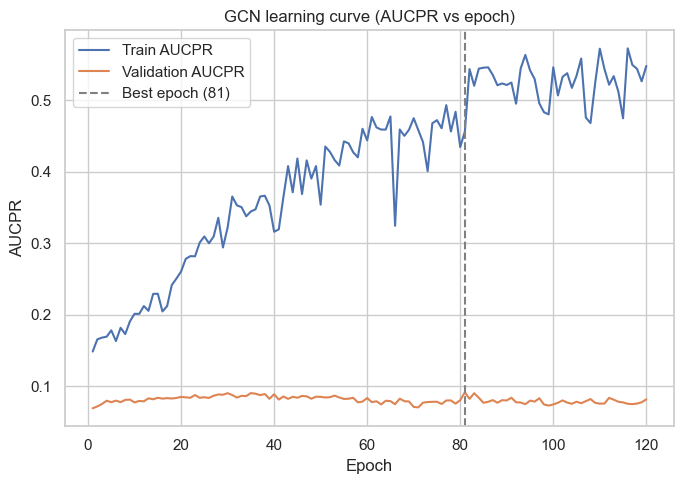

Early stopping at epoch 35 (validation AUCPR = 0.091)
GCN test AUCPR = 0.069   |   gradient-boosted trees test AUCPR = 0.117


In [17]:
import copy
from sklearn.metrics import average_precision_score
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

device = torch.device('cpu')
NUM_NODE_FEATURES = dataset.num_node_features

# Class weights to counteract the strong imbalance of the training set.
_train_labels = np.array([int(data.y) for data in train_dataset])
_class_counts = np.bincount(_train_labels, minlength=2)
class_weights = torch.tensor(len(_train_labels) / (2.0 * _class_counts), dtype=torch.float32, device=device)


class FlexibleGCN(torch.nn.Module):
    """Graph convolution network with a configurable width and depth."""

    def __init__(self, hidden_channels, num_layers=1, seed=12345):
        super().__init__()
        torch.manual_seed(seed)
        self.node_embedding = Linear(NUM_NODE_FEATURES, hidden_channels)
        self.convs = torch.nn.ModuleList(GCNConv(hidden_channels, hidden_channels) for _ in range(num_layers))
        self.lin = Linear(hidden_channels, 2)

    def forward(self, node_features, edge_features, edge_index, batch):
        x = self.node_embedding(node_features).relu()
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)


@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs = []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        probs.append(torch.softmax(out, dim=1)[:, 1].cpu())
    return torch.cat(probs).numpy()


@torch.no_grad()
def evaluate(model, loader, loss_function):
    model.eval()
    probs, labels, total_loss = [], [], 0.0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        total_loss += float(loss_function(out, data.y)) * data.num_graphs
        probs.append(torch.softmax(out, dim=1)[:, 1].cpu())
        labels.append(data.y.cpu())
    probs = torch.cat(probs).numpy()
    labels = torch.cat(labels).numpy()
    return total_loss / len(loader.dataset), average_precision_score(labels, probs)


def run_training(model, n_epochs=80, lr=0.01, patience=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)
    history = {'train_loss': [], 'val_loss': [], 'train_aucpr': [], 'val_aucpr': []}
    best_val, best_state, best_epoch, wait = -1.0, None, 0, 0
    for epoch in range(1, n_epochs + 1):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_attr, data.edge_index, data.batch)
            loss = loss_function(out, data.y)
            loss.backward()
            optimizer.step()
        train_loss, train_aucpr = evaluate(model, train_loader, loss_function)
        val_loss, val_aucpr = evaluate(model, validation_loader, loss_function)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_aucpr'].append(train_aucpr)
        history['val_aucpr'].append(val_aucpr)
        if val_aucpr > best_val:
            best_val, best_epoch, best_state, wait = val_aucpr, epoch, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if patience is not None and wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    history['best_val_aucpr'] = best_val
    return model, history


# Part (a): train long enough to expose overfitting and plot the AUCPR learning curves.
model_a, history_a = run_training(FlexibleGCN(hidden_channels=16, num_layers=1), n_epochs=120)
epochs = np.arange(1, len(history_a['train_aucpr']) + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs, history_a['train_aucpr'], label='Train AUCPR')
ax.plot(epochs, history_a['val_aucpr'], label='Validation AUCPR')
ax.axvline(history_a['best_epoch'], ls='--', color='grey', label=f"Best epoch ({history_a['best_epoch']})")
ax.set_xlabel('Epoch')
ax.set_ylabel('AUCPR')
ax.set_title('GCN learning curve (AUCPR vs epoch)')
ax.legend()
plt.tight_layout()
plt.show()

# Part (b): retrain with early stopping on the validation AUCPR and report the test score.
model_b, history_b = run_training(FlexibleGCN(hidden_channels=16, num_layers=1), n_epochs=200, patience=20)
gcn_test_aucpr = average_precision_score(y_test, predict_probs(model_b, test_loader))
print(f'Early stopping at epoch {history_b["best_epoch"]} (validation AUCPR = {history_b["best_val_aucpr"]:.3f})')
print(f'GCN test AUCPR = {gcn_test_aucpr:.3f}   |   gradient-boosted trees test AUCPR = {test_aucpr:.3f}')

**Answer**

a. Looking at the epoch-score graph we can see that the validation AUCPR peaks early, and after that it stays about the same/drops a bit, while the train AUCPR keeps climbing - a clear sign of overfitting. Early stopping fires at epoch 35.

b. The performance on the test set is 0.069 with the early stop, which is below the feature based model (0.117) - it seems to lack information.

12.	How many parameters does the GCN have, as function of the number of layers and of the dimension of the node features?

**Answer.** Let $d$ be the input node feature dimension, $h$ the hidden width and $L$ the number of `GCNConv` layers. The model has three parts:

- input embedding `Linear(d, h)`: $d h + h$ parameters;
- graph convolution `GCNConv(h, h)`: a weight matrix plus bias, $h^2 + h$ parameters, repeated $L$ times;
- classifier `Linear(h, 2)`: $2h + 2$ parameters.

In total:
$$ N(h, L) = \underbrace{(d h + h)}_{\text{embedding}} + L\,\underbrace{(h^2 + h)}_{\text{convolutions}} + \underbrace{(2h + 2)}_{\text{classifier}} = L\,h^2 + (d + L + 3)\,h + 2. $$

So the parameter count grows **linearly** with the depth $L$ and **quadratically** with the width $h$, and for any non-trivial width the $L h^2$ convolution term dominates. With the dataset's $d = 23$ node features and $h = 64$, $L = 1$, that's about $64^2 + 27 \cdot 64 + 2 \approx 5{,}900$ parameters.

13.	Varying the network width: Train GCNs with varying node feature dimensions ([16,32,64,128] ) and plot the learning curves of the model (loss vs number of epochs) on the training and validation sets. Are there signs of overfitting? Why?



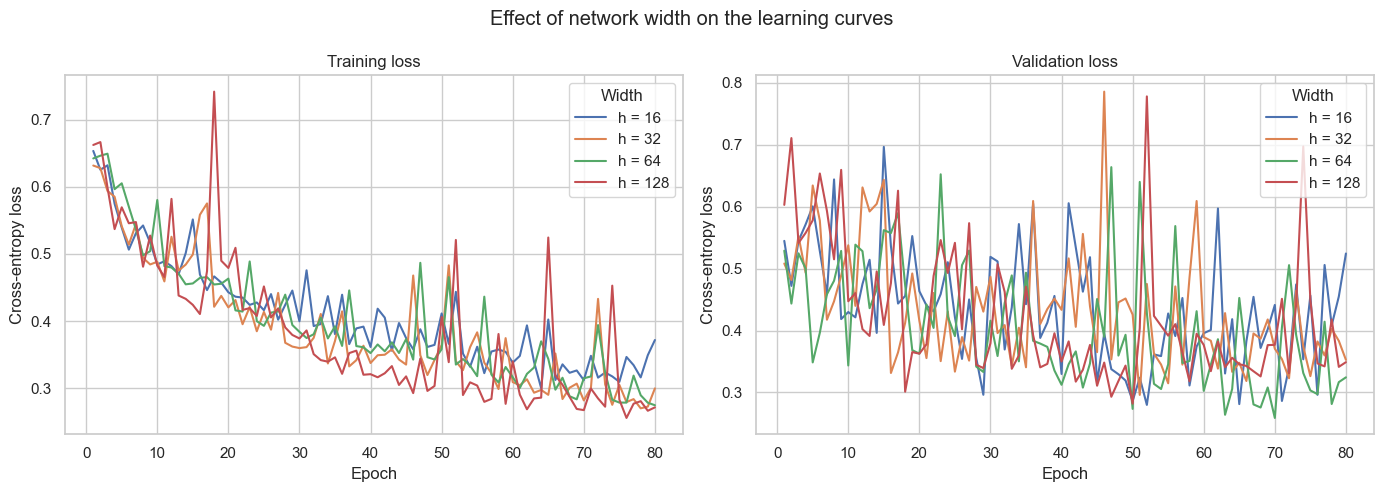

Width   params   best val AUCPR
   16      962   0.197
   32     2946   0.098
   64     9986   0.207
  128    36354   0.126


In [18]:
widths = [16, 32, 64, 128]
width_histories = {}
for h in widths:
    _, width_histories[h] = run_training(FlexibleGCN(hidden_channels=h, num_layers=2), n_epochs=80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for h in widths:
    ep = np.arange(1, len(width_histories[h]['train_loss']) + 1)
    axes[0].plot(ep, width_histories[h]['train_loss'], label=f'h = {h}')
    axes[1].plot(ep, width_histories[h]['val_loss'], label=f'h = {h}')
axes[0].set_title('Training loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend(title='Width')
fig.suptitle('Effect of network width on the learning curves')
plt.tight_layout()
plt.show()

print('Width   params   best val AUCPR')
for h in widths:
    n_params = sum(p.numel() for p in FlexibleGCN(hidden_channels=h, num_layers=2).parameters())
    print(f'{h:5d}   {n_params:6d}   {width_histories[h]["best_val_aucpr"]:.3f}')

**Answer**

The width does not show a clean trend. The best validation AUCPR jumps around with width (about 0.20, 0.10, 0.21, 0.13 for widths 16, 32, 64, 128), and the validation set has only a handful of actives, so these gaps are mostly noise. The loss curves still show some overfitting, with the training loss dropping while the validation loss flattens at the higher epochs.

14.	Varying the network depth and the oversmoothing effect: Train GCNs with varying number of layers ([1, 3,5,10]), and (approximately) fixed number of parameters, and plot the learning curves of the model. Are there signs of overfitting? Underfitting? Why?

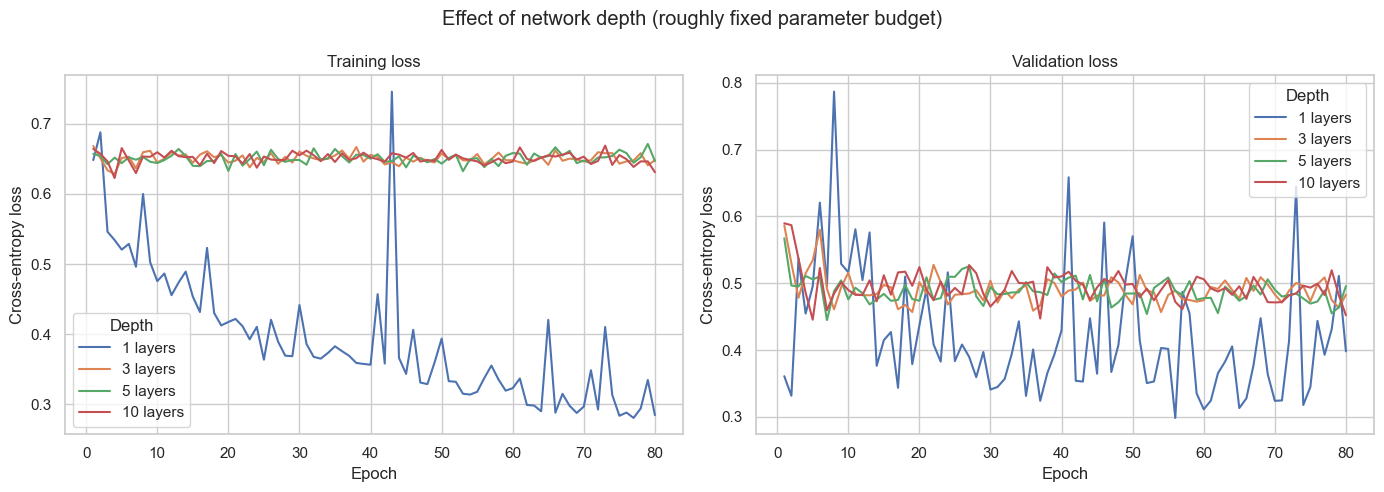

Layers   width   params   best val AUCPR
     1     128    19842   0.109
     3      74    18576   0.094
     5      57    18014   0.179
    10      40    17442   0.066


In [19]:
# Vary depth while keeping the parameter count roughly constant by shrinking the
# width as the depth grows (the convolution term scales like L * h^2, so h ~ 1/sqrt(L)).
depths = [1, 3, 5, 10]
depth_configs = {L: max(8, round(128 / np.sqrt(L))) for L in depths}
depth_histories = {}
for L, h in depth_configs.items():
    _, depth_histories[L] = run_training(FlexibleGCN(hidden_channels=h, num_layers=L), n_epochs=80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for L in depths:
    ep = np.arange(1, len(depth_histories[L]['train_loss']) + 1)
    axes[0].plot(ep, depth_histories[L]['train_loss'], label=f'{L} layers')
    axes[1].plot(ep, depth_histories[L]['val_loss'], label=f'{L} layers')
axes[0].set_title('Training loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend(title='Depth')
fig.suptitle('Effect of network depth (roughly fixed parameter budget)')
plt.tight_layout()
plt.show()

print('Layers   width   params   best val AUCPR')
for L in depths:
    h = depth_configs[L]
    n_params = sum(p.numel() for p in FlexibleGCN(hidden_channels=h, num_layers=L).parameters())
    print(f'{L:6d}   {h:5d}   {n_params:6d}   {depth_histories[L]["best_val_aucpr"]:.3f}')

**Answer**

Depth does not show a clean trend either. The best validation AUCPR is roughly 0.11, 0.09, 0.18, 0.07 for 1, 3, 5 and 10 layers, so there is no steady gain or loss with depth and the 10-layer model is the weakest. With so few validation actives these numbers are very noisy, so the ordering should not be read too literally. The curves look more like mild underfitting than overfitting, which fits how hard these small GCNs are to train on few positives.

15.	Virtual screening: Pick the best GNN, and use it to predict antimicrobial activity on the evaluation set. How do the predictions correlate with the ones of the D-MPNN model? Does it predict halicin to have an activity?

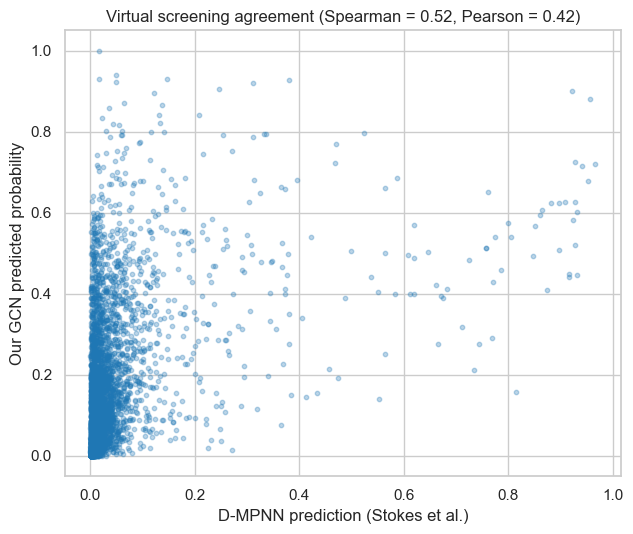

Spearman correlation with the D-MPNN model: 0.519
Pearson correlation with the D-MPNN model:  0.421
GCN predicted probability of activity for halicin: 0.795

Top 10 evaluation molecules ranked by our GCN:
 1. perfluorodecalin               GCN = 1.000  D-MPNN = 0.017
 2. malotilate                     GCN = 0.941  D-MPNN = 0.048
 3. 4,5,6,7-tetrabromobenzotriazole GCN = 0.931  D-MPNN = 0.016
 4. VX-702                         GCN = 0.930  D-MPNN = 0.147
 5. tetroquinone                   GCN = 0.928  D-MPNN = 0.381
 6. AS-604850                      GCN = 0.923  D-MPNN = 0.049
 7. 5-FP                           GCN = 0.919  D-MPNN = 0.312
 8. P22077                         GCN = 0.906  D-MPNN = 0.245
 9. trovafloxacin                  GCN = 0.902  D-MPNN = 0.921
10. favipiravir                    GCN = 0.896  D-MPNN = 0.121


In [20]:
from scipy.stats import spearmanr, pearsonr

# Best GNN: retrain the early-stopping GCN configuration and score the evaluation set.
best_gnn, _ = run_training(FlexibleGCN(hidden_channels=16, num_layers=2), n_epochs=200, patience=20)
eval_scores = predict_probs(best_gnn, evaluation_loader)

dmpnn_scores = table_evaluation_molecules['Pred_Score'].values
spearman_rho = spearmanr(eval_scores, dmpnn_scores).statistic
pearson_r = pearsonr(eval_scores, dmpnn_scores).statistic

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(dmpnn_scores, eval_scores, s=10, alpha=0.3, color='tab:blue')
ax.set_xlabel('D-MPNN prediction (Stokes et al.)')
ax.set_ylabel('Our GCN predicted probability')
ax.set_title(f'Virtual screening agreement (Spearman = {spearman_rho:.2f}, Pearson = {pearson_r:.2f})')
plt.tight_layout()
plt.show()

# Score halicin directly from its SMILES.
halicin_graph = molecule_to_graph(Chem.MolFromSmiles('Nc1nnc(Sc2ncc([N+](=O)[O-])s2)s1'))
halicin_loader = DataLoader(CustomGraphDataset([halicin_graph]), batch_size=1)
halicin_score = float(predict_probs(best_gnn, halicin_loader)[0])

print(f'Spearman correlation with the D-MPNN model: {spearman_rho:.3f}')
print(f'Pearson correlation with the D-MPNN model:  {pearson_r:.3f}')
print(f'GCN predicted probability of activity for halicin: {halicin_score:.3f}')

top10 = np.argsort(eval_scores)[::-1][:10]
print('\nTop 10 evaluation molecules ranked by our GCN:')
for rank, idx in enumerate(top10, 1):
    print(f'{rank:2d}. {table_evaluation_molecules["Name"].iloc[idx]:30s} GCN = {eval_scores[idx]:.3f}  D-MPNN = {dmpnn_scores[idx]:.3f}')

**Answer**
The GCN predictions have a moderate positive correlation with the published D-MPNN predictions on the evaluation set (Spearman correlation = 0.52; Pearson correlation = 0.42). Thus, the two models tend to rank molecules similarly overall, but their agreement is far from exact. we can see that some molecules ranked high by the GC are ranked very low by the D-MPNN, which is concerning (or exciting - new potential molecules)

On a positive note, The GCN predicts halicin to be active, with a predicted activity probability of 0.80. (above 0.5), so halicin would be predicted as a antimicrobial hit by this model.


Bonus: So far, we did not use at all the edge features (i.e., whether a chemical bond is a simple, double, aromatic bond, etc.). Build a Message-Passing Neural Network that integrate these features and compare the performance of the model with the one of the GCN.

In [21]:
from torch_geometric.nn import GINEConv


class MPNN(torch.nn.Module):
    """Message-passing network that conditions messages on the bond (edge) features."""

    def __init__(self, hidden_channels=64, num_layers=2, seed=12345):
        super().__init__()
        torch.manual_seed(seed)
        self.node_embedding = Linear(NUM_NODE_FEATURES, hidden_channels)
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            mlp = torch.nn.Sequential(
                Linear(hidden_channels, hidden_channels), torch.nn.ReLU(),
                Linear(hidden_channels, hidden_channels),
            )
            self.convs.append(GINEConv(mlp, edge_dim=5))
        self.lin = Linear(hidden_channels, 2)

    def forward(self, node_features, edge_features, edge_index, batch):
        x = self.node_embedding(node_features).relu()
        for conv in self.convs:
            x = conv(x, edge_index, edge_features).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)


mpnn, mpnn_history = run_training(MPNN(hidden_channels=16, num_layers=2), n_epochs=200, patience=20)
mpnn_test_aucpr = average_precision_score(y_test, predict_probs(mpnn, test_loader))

print(f'MPNN (with edge features) test AUCPR = {mpnn_test_aucpr:.3f}')
print(f'GCN  (no edge features)   test AUCPR = {gcn_test_aucpr:.3f}')
print(f'Gradient-boosted trees    test AUCPR = {test_aucpr:.3f}')

MPNN (with edge features) test AUCPR = 0.038
GCN  (no edge features)   test AUCPR = 0.069
Gradient-boosted trees    test AUCPR = 0.117


**Answer**

The message-passing network does not add to the GCN here: its test AUCPR (0.038) is below the plain GCN (0.069). This is probably because the edge attributes are already partly coded in the low-level node features such as ring membership.

## Bonus: how the corrected split changed the results

The fix removed a nested-indexing bug that leaked some train molecules into the test slice, then rebalanced the group split (similarity cut-off raised to 0.5, GroupKFold) so the old mega-group no longer dominates. The base GNN was also shrunk to hidden size 16 and regularized with weight decay.

| | Before | After |
|---|---|---|
| groups | ~477 | 1138 |
| train / val / test | 1983 / 177 / 174 | 1638 / 312 / 384 |
| positive rate (train/val/test) | 0.039 / 0.051 / 0.195 | 0.052 / 0.058 / 0.044 |
| fold positive rate | [0, 0, 0.014, 0.051, 0.047] | [0.039, 0.013, 0.049, 0.081, 0.073] |

Before, the test set was about 4x too active-rich and two folds had zero actives (AUCPR undefined there). After, the test rate (0.044) sits near the 0.05 prevalence and every fold has actives.

Model effect: the gradient-boosted trees reach a test AUCPR of 0.117, about 2.6x the 0.044 baseline. The GCN reaches 0.069 and the edge-feature MPNN 0.038. The GCN still flags halicin as active (0.80) and correlates moderately with the D-MPNN (Spearman 0.52). The scores are lower than on the old leaky split, but they are a fair estimate of how these models generalize.